### assumtions of lienar regression
1. linear relationship between input and output
2. no multicolinearity
3. Homoscedasticity
4. normality of residual
5. no autocorelation of errors

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=  pd.read_csv("data.csv")

In [8]:
df.head()

,feature1,feature2,feature3,target
0,-0.570563,1.420342,0.495580,-9.763182
1,-0.990563,0.556965,1.045064,-24.029355
2,-0.674728,0.150617,1.774645,45.616421
3,0.388250,-0.387127,-0.110229,34.135737
4,1.167882,-0.024104,0.145063,86.663647


In [9]:
x=df.iloc[: ,0:3].values

In [10]:
y= df.iloc[: , -1 ].values

In [11]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split(x, y , test_size=0.3 , random_state= 1)

In [13]:
from sklearn.linear_model import LinearRegression
model= LinearRegression()
model.fit(x_train , y_train )

LinearRegression()

In [15]:
y_pred= model.predict(x_test)

In [16]:
residual= y_test- y_pred

# 1. linear relationship

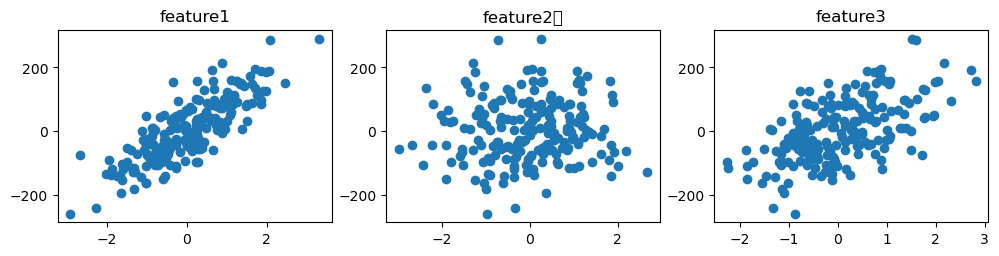

In [23]:
fig , (ax1 , ax2 , ax3)= plt.subplots(ncols=3 , figsize=(12, 2.5))
ax1.scatter(df["feature1"], df['target'])
ax1.set_title('feature1')
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("feature2	")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("feature3")
plt.show()

observations : feature1 ,and feature3 are linear to target feacture

#  2. No Multicoliniarity 

In [31]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif= []
for i in range(x_train.shape[1]):
    vif.append(variance_inflation_factor(x_train, i))

In [32]:
pd.DataFrame({'vif':vif}, index= df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.010326,1.009871,1.01395


In [33]:
# observations : if vif ~ 1 -> no multicolinarity 
# if vif >= 5 -> there is multicoliniarity

In [34]:
# another technique

<Axes: >

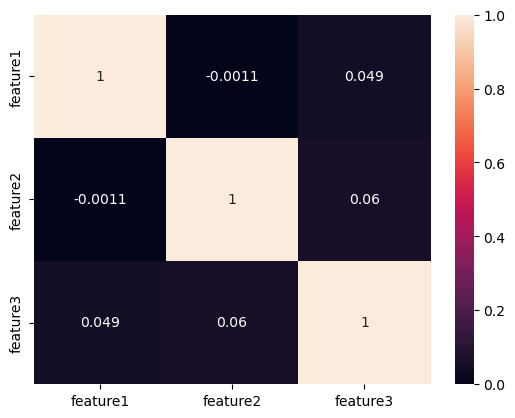

In [35]:
import seaborn as sns
sns.heatmap(df.iloc[: , 0:3].corr() , annot= True)

In [36]:
# observations 
# see the corelations between features , below and above the diagonal
# as all are very less , no multicolinarity


# 3 . NOrmality of residuals

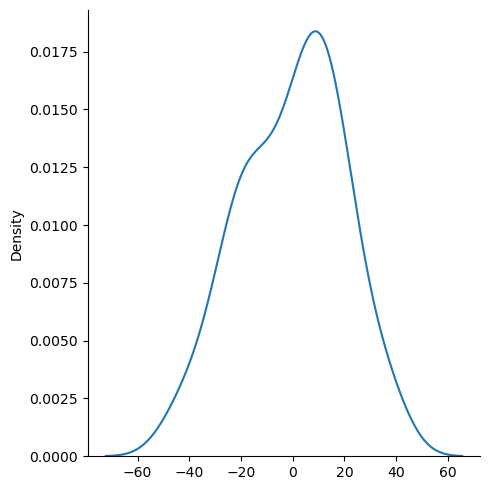

In [37]:
sns.displot(residual   , kind= 'kde' )

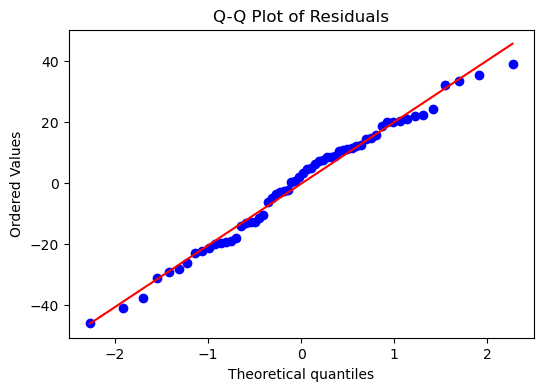

In [43]:
# qq plot
import scipy.stats as stats
import matplotlib.pyplot as plt

# Example: residual is your residual array
# residual = model.resid or (y_true - y_pred)

fig, ax = plt.subplots(figsize=(6, 4))
stats.probplot(residual, plot=ax, fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()


# observations : 
approx normaly dist data

# 4. Homoscedasticity
"having the same scatter"
The variance of the residuals (errors) is constant across all levels of the independent variable(s).

In simpler terms:

The spread of residuals should stay roughly the same for all predicted (fitted) values.
If the spread increases or decreases, that’s heteroscedasticity, which violates the assumption.


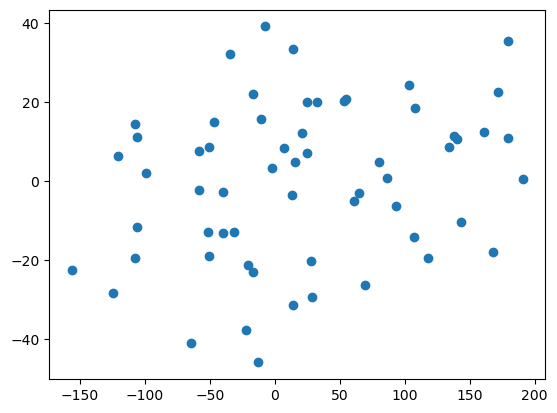

In [44]:
plt.scatter(y_pred  , residual)

In [45]:
#observations : 
 #homoscadsity is followed

# 5. No autocorrelation of error

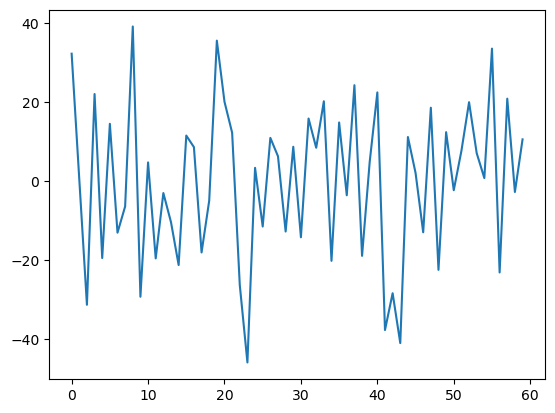

In [46]:
plt.plot(residual)

In [47]:
# observations : no relations betweeen the residuals/ errors